#  Исследование результатов А/В-теста и поиск инсайтов


SollmaFin — международное мобильное приложение для онлайн-торговли финансовыми активами. Пользователи могут инвестировать деньги в акции, валюту, криптовалюту, биржевые фонды (ETF) и другие активы. Целевая аудитория приложения — начинающие инвесторы. Получить доступ к финансовым рынкам можно со смартфона либо через веб-версию. 

Приложение ориентировано на рынок Латинской Америки с акцентом на четыре страны: Мексику, Бразилию, Колумбию и Аргентину — там быстро растёт интерес к финтеху и инвестициям, а экономики очень разные. 

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.
Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений. 

### А/В-эксперимент

В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года. 
Пользователей случайным образом разделили на две равные группы: 
- Контрольная группа проходила стандартный онбординг без обязательного обучения.
- Тестовая группа проходила обновлённый онбординг с подробной информацией об активах и связанных с ними рисках. 

После разделения активность пользователей анализировали в течение недели.

Цель эксперимента — оценить, как обновлённый онбординг влияет на поведение пользователей и их дальнейшую инвестиционную активность.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- Гипотеза риска: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- Дополнительная гипотеза: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита. 

Чтобы увидеть полную картину, недостаточно следить за метриками конверсии. Команда выбрала для эксперимента такой набор метрик: 
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Ожидалось, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост. 

### Задачи
Изучим исторические данные и проведем полный анализ результатов А/В-эксперимента.    

#### 1. Анализ исторических данных

Чтобы понять, для чего была разработана новая фича, изучим исторические данные: 
- Поведение новых пользователей, в том числе динамику привлечения, сегментацию и ключевые этапы воронки действий.
- Метрики, связанные с внесением депозитов, в том числе средние суммы депозитов. 

#### 2. Анализ данных А/В-теста

Изучение результатов эксперимента будет состоять из двух этапов: 
- Сравнение поведения пользователей в контрольной и тестовой группах, оценка статистической значимости изменений. 
- Исследование влияния нового онбординга на поведение платящих пользователей. В исследовании вы будете использовать бутстрап и сосредоточитесь на нижних и верхних перцентилях распределения депозитов. 
- Такой подход позволит понять, как обновлённый онбординг повлиял на ключевые бизнес-метрики, найти точки роста и сформулировать рекомендации по улучшению пользовательского опыта и монетизации.


### Данные

Данные прдеставлены в двух датасетах:  

1. Датасет `/datasets/pa_sollmafin_hist.csv` содержит исторические данные о ключевых действиях новых пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно. В датасете собраны действия пользователей до оформления второго депозита. 
2. Датасет `/datasets/pa_sollmafin_abt.csv` содержит данные А/В-эксперимента — все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей. Пользователи уже распределены по группам А/В-эксперимента.

Общие поля датасетов:
- `user_id` — уникальный идентификатор пользователя;
- `country_code` — код страны пользователя в формате ISO (например, `BR` — Бразилия, `MX` — Мексика, `AR` — Аргентина, `CO` — Колумбия);
- `platform` — устройство, с которого пользователь взаимодействует с продуктом: mobile или web;
- `first_ts` — время первого появления пользователя в системе;
- `first_dt` — дата первого появления пользователя (без времени);
- `event_ts` — время события;
- `event_name` — название события;
- `amount` — сумма пополнения депозита;
- `asset` — тип приобретённого актива; 
- `risk_level` — уровень риска актива: low — низкий риск, medium — средний риск, high — высокий риск.

В датасете `/datasets/pa_sollmafin_abt.csv` содержатся два дополнительных поля:
- `ab_test` — название А/В-эксперимента;
- `group` — пользовательская группа А/В-эксперимента.


### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы


---
<a class="anchor" id="data-loading-and-preprocessing"></a>
## 1 Загрузка исторических данных и их предобработка

Загрузим данные из датасета `/datasets/pa_sollmafin_hist.csv` и получим основную информацию о них. Проведем предобработку. Зафиксируем основную информацию о данных и предобработке в кратком промежуточном выводе.

In [1]:
# Импортируем библиотеки для работы с данными и визуализациями
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
import numpy as np

In [2]:
# Выгружаем данные сервиса доставки еды
df_hist = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv', 
                     parse_dates=['first_ts', 'first_dt', 'event_ts'])
 
display(df_hist.head())
print()
df_hist.info()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


Данные представлены корректными типами данных.
- Посмотрим какое количество уникальных пользователей и какие страны, платформы, названия событий, типы активов и уровни риска  представлены в датасете.

In [3]:
# Выводим количество уникальных значений в колонке user_id и значения в country_code, platform, event_name, asset, risk_level
print(f"Количество уникальных значений user_id - {df_hist['user_id'].nunique()}.") 

summary = (
    df_hist[['country_code', 'platform', 'event_name', 'asset', 'risk_level']]
    .apply(lambda x: ", ".join(sorted(x.dropna().unique())))
    .reset_index()
)

summary.columns = ['column', 'unique_values']
pd.set_option('display.max_colwidth', None)
display(summary)

Количество уникальных значений user_id - 41032.


,column,unique_values
0,country_code,"AR, BR, CO, MX"
1,platform,"mobile, web"
2,event_name,"asset_purchase, first_deposit, install / open_web, introduction, main_page, onboarding_complete, registration, second_deposit"
3,asset,"crypto, option, stock"
4,risk_level,"high, low, medium"


В датасете представлены все ключевые сущности пользовательского пути: страны, платформы, события воронки, а также характеристики инвестиционных активов.

- Проверим интервал дат первого появления пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно.

In [4]:
# Проверим интервал дат событий
start_date = df_hist['first_dt'].min()
end_date = df_hist['first_dt'].max()

print(f'Период данных: с {start_date} по {end_date}')

Период данных: с 2025-04-01 00:00:00 по 2025-06-01 00:00:00


- Проверим интервал дат событий.

In [5]:
# Проверим интервал дат событий
start_date = df_hist['event_ts'].min()
end_date = df_hist['event_ts'].max()

print(f'Период данных: с {start_date} по {end_date}')

Период данных: с 2025-04-01 00:06:34 по 2025-06-09 20:24:42


События выходят за пределы периода привлечения пользователей, так как отражают дальнейшее поведение пользователей после регистрации, что соответствует логике A/B-эксперимента.

- Проверим данные на наличие дубликатов.

In [6]:
# Количество полных дубликатов
full_duplicates = df_hist.duplicated().sum()
print(f'Количество полных дубликатов строк: {full_duplicates}')

Количество полных дубликатов строк: 0


In [7]:
# Проверим дубликаты событий внутри одного события
event_duplicates = (
    df_hist
    .duplicated(subset=['user_id', 'event_ts', 'event_name'])
    .sum()
)

print(f'Неявные дубликаты событий: {event_duplicates}')

Неявные дубликаты событий: 0


In [8]:
# Проверим дубликаты событий первого депозита
first_deposit_duplicates = (
    df_hist[df_hist['event_name'] == 'first_deposit']
    .duplicated(subset=['user_id'])
    .sum()
)

print(f'Неявные дубликаты событий: {first_deposit_duplicates}')

Неявные дубликаты событий: 0


In [9]:
# Проверим дубликаты событий второго депозита
second_deposit_duplicates = (
    df_hist[df_hist['event_name'] == 'second_deposit']
    .duplicated(subset=['user_id'])
    .sum()
)

print(f'Неявные дубликаты событий: {second_deposit_duplicates}')

Неявные дубликаты событий: 0


In [10]:
# Проверим дубликаты событий покупки активов
asset_purchase_duplicates = (
    df_hist[df_hist['event_name'] == 'asset_purchase']
    .duplicated(subset=['user_id', 'event_ts', 'asset', 'amount'])
    .sum()
)

print(f'Неявные дубликаты событий: {asset_purchase_duplicates}')

Неявные дубликаты событий: 0


In [11]:
# Проверим дубликаты уникальных событий
single_events = [
    'install / open_web',
    'introduction',
    'registration',
    'onboarding_complete'
]

single_events_duplicates = (
    df_hist[df_hist['event_name'].isin(single_events)]
    .duplicated(subset=['user_id', 'event_name'])
    .sum()
)

print(f'Неявные дубликаты событий: {single_events_duplicates}')

Неявные дубликаты событий: 0


- В рамках этапа предобработки были загружены и изучены исторические данные о ключевых действиях новых пользователей SollmaFin, привлечённых в период с 1 апреля по 1 июня 2025 года включительно.

Датасет `df_hist` содержит 10 столбцов и 238 059 строк с данными. 
Данные представлены за период с 1 апреля по 9 июня 2025 года и отражают событийную историю взаимодействия пользователей с сервисом.

После первичного анализа данных можно сделать следующие выводы:
- Большинство столбцов представлены корректными типами данных. 
- Столбцы `first_ts`, `first_dt`, `event_ts` успешно преобразованы в формат `datetime`, что позволяет анализировать пользовательское поведение во времени.
- Три столбца содержат пропуски: `amount`, `asset`, `risk_level`. Наличие пропусков в данных столбцах обусловлено тем, что данные заполняются только для событий покупки активов и отсутствуют для технических и навигационных событий. Дополнительной обработки пропусков не требуется.
- В датасете представлены 41 032 уникальных зарегистрированных пользователя (`user_id`).
- Полные дубликаты строк отсутствуют.
- Неявные дубликаты событий не выявлены.

Данные имеют хорошее качество и не содержат критических ошибок, пропусков или дубликатов, искажающих бизнес-логику.
Датасет полностью готов для дальнейшего анализа.

## 2 Исследовательский анализ исторических данных

Проведем исследовательский анализ исторических данных. По каждой подзадаче сделаем промежуточный вывод. 

<a class="anchor" id="new-user-analysis"></a>
### 2.1 Анализ новых пользователей
- Изучим динамику привлечения новых пользователей в приложение и ответим на вопросы:
    - Сколько новых пользователей приходит? Стабилен ли приток?
    - Из каких стран и с каких платформ они приходят?
    - Можно ли считать аудиторию однородной?

In [12]:
# Подготовим таблицу новых пользователей
users = (
    df_hist[['user_id', 'first_dt', 'country_code', 'platform']]
    .drop_duplicates(subset=['user_id'])
)

display(users.head())
users.shape

,user_id,first_dt,country_code,platform
0,548ac59f-656d-4110-80d2-49f0a217f08a,2025-04-02,BR,mobile
6,89923614-c303-414d-9788-b5ed77ccc740,2025-05-12,BR,mobile
13,df7b9aae-7475-4878-a8c7-9bd3002fa226,2025-04-30,BR,mobile
20,f18e66dc-e9dd-4608-b067-716ec62f4e70,2025-04-26,AR,mobile
27,9445729e-951a-4573-98de-70d9322af290,2025-04-06,CO,mobile


(41032, 4)

- Рассмотрим сколько новых пользователей приходит по дням.

In [13]:
# Количество новых пользователей по дням
users_by_day = (
    users
    .groupby('first_dt')
    .agg(new_users=('user_id', 'nunique'))
    .reset_index()
)

display(users_by_day.head())
users_by_day['new_users'].describe()

,first_dt,new_users
0,2025-04-01,670
1,2025-04-02,676
2,2025-04-03,691
3,2025-04-04,637
4,2025-04-05,640


count     62.000000
mean     661.806452
std       23.425388
min      613.000000
25%      646.500000
50%      663.000000
75%      682.750000
max      713.000000
Name: new_users, dtype: float64

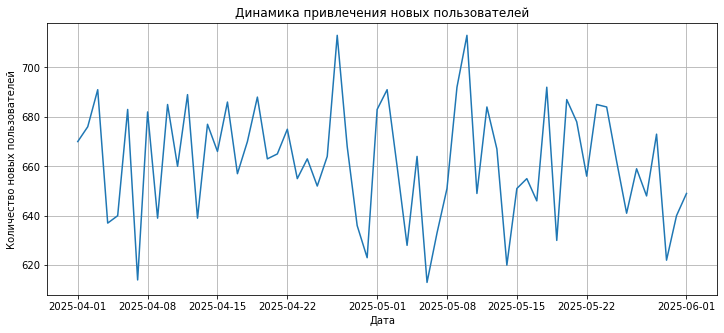

In [14]:
# Построим график 
plt.figure(figsize=(12, 5))
plt.plot(users_by_day['first_dt'], users_by_day['new_users'])
plt.title('Динамика привлечения новых пользователей')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')
plt.grid(True)
plt.show()

Анализ количества новых пользователей по дням за период с 1 апреля по 1 июня 2025 года показал:
- В среднем ежедневно регистрируется около 662 новых пользователей.
- Минимальное значение за день - 613, максимальное - 713, стандартное отклонение - 23, что указывает на невысокую вариативность потока.
- Наибольший интерес вызывают два дня с пиками около 710–713 пользователей, что может быть связано с маркетинговыми активностями, но они не влияют на общую стабильность потока. 
- Два дня с минимумом около 613 пользователей могут быть обусловлены выходными, но также не нарушают общую однородность потока.

Посмотрим на распределение новых пользователей по странам.

In [15]:
# Количество новых пользователей по странам
users_by_country = (
    users
    .groupby('country_code')
    .agg(users=('user_id', 'nunique'))
    .reset_index()
    .sort_values('users', ascending=False)
)

users_by_country['share'] = round(users_by_country['users'] / users_by_country['users'].sum() * 100, 2)

display(users_by_country)

,country_code,users,share
1,BR,12266,29.89
3,MX,11303,27.55
2,CO,9974,24.31
0,AR,7489,18.25


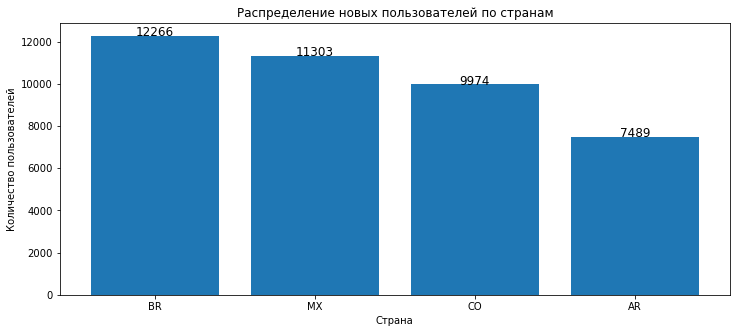

In [16]:
# Построим график 
plt.figure(figsize=(12, 5))
bars_country = plt.bar(users_by_country['country_code'], users_by_country['users'])

# Перебираем в цикле значения, которые мы только что отобразили
for bar in bars_country:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', fontsize=12)

plt.title('Распределение новых пользователей по странам')
plt.xlabel('Страна')
plt.ylabel('Количество пользователей')
plt.show()

- Ознакомимся с динамикой новых пользователей по региону.

In [17]:
# Динамика новых пользователей по дням и странам
users_by_day_country = (
    users
    .groupby(['first_dt', 'country_code'])
    .agg(new_users=('user_id', 'nunique'))
    .reset_index()
)

display(users_by_day_country.head())

,first_dt,country_code,new_users
0,2025-04-01,AR,128
1,2025-04-01,BR,201
2,2025-04-01,CO,154
3,2025-04-01,MX,187
4,2025-04-02,AR,131


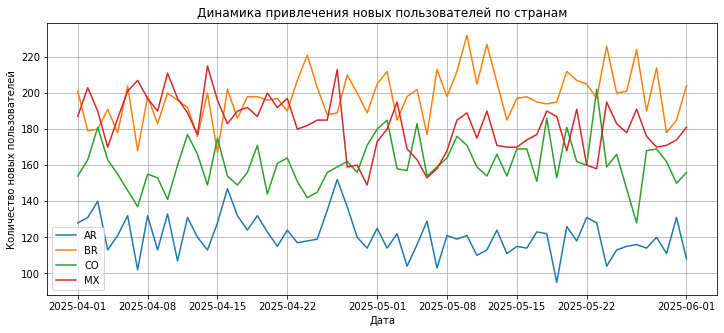

In [18]:
# Построим график
plt.figure(figsize=(12, 5))

for country in users_by_day_country['country_code'].unique():
    plot = users_by_day_country[users_by_day_country['country_code'] == country]
    plt.plot(plot['first_dt'], plot['new_users'], label=country)

plt.title('Динамика привлечения новых пользователей по странам')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')
plt.legend()
plt.grid()
plt.show()

- Основная часть пользователей приходит из Бразилии и Мексики, при этом график динамики по странам демонстрирует высокую волатильность ежедневных регистраций. Аргентина показывает наиболее скромный, но при этом самый стабильный результат без резких перепадов. Несмотря на ежедневные колебания, на графиках не наблюдается глобальных просадок или неестественных всплесков в конкретные даты, что подтверждает корректность работы рекламных каналов во всех четырех странах.

Посмотрим на распределение новых пользователей по платформам.

In [19]:
# Количество новых пользователей по платфлормам
users_by_platform = (
    users
    .groupby('platform')
    .agg(users=('user_id', 'nunique'))
    .reset_index()
    .sort_values('users', ascending=False)
)

users_by_platform['share'] = round(users_by_platform['users'] / users_by_platform['users'].sum() * 100, 2)

display(users_by_platform)

,platform,users,share
0,mobile,28758,70.09
1,web,12274,29.91


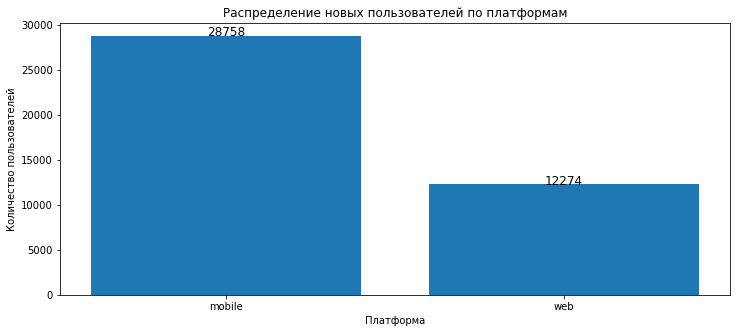

In [20]:
# Построим график 
plt.figure(figsize=(12, 5))
bars_platform = plt.bar(users_by_platform['platform'], users_by_platform['users'])

# Перебираем в цикле значения, которые мы только что отобразили
for bar in bars_platform:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', fontsize=12)

plt.title('Распределение новых пользователей по платформам')
plt.xlabel('Платформа')
plt.ylabel('Количество пользователей')
plt.show()

- Посмотрим на динамику новых пользователей по платформам (web / mobile).

In [21]:
# Динамика новых пользователей по дням и платформам
users_by_day_platform = (
    users
    .groupby(['first_dt', 'platform'])
    .agg(new_users=('user_id', 'nunique'))
    .reset_index()
)

display(users_by_day_platform.head())

,first_dt,platform,new_users
0,2025-04-01,mobile,474
1,2025-04-01,web,196
2,2025-04-02,mobile,479
3,2025-04-02,web,197
4,2025-04-03,mobile,493


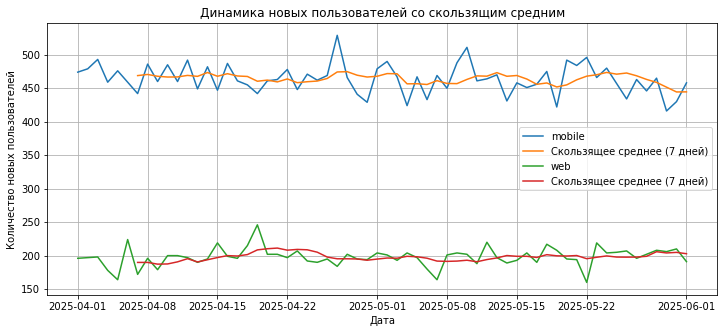

In [22]:
# Добавим скользящее среднее за 7 дней
users_by_day_platform['rolling_7d'] = (
    users_by_day_platform
    .sort_values('first_dt')
    .groupby('platform')['new_users']
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

# Построим график
plt.figure(figsize=(12, 5))

for platform in users_by_day_platform['platform'].unique():
    plot = users_by_day_platform[users_by_day_platform['platform'] == platform]
    plt.plot(plot['first_dt'], plot['new_users'], label=platform)
    plt.plot(plot['first_dt'], plot['rolling_7d'], label='Скользящее среднее (7 дней)')

plt.title('Динамика новых пользователей со скользящим средним')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')
plt.legend()
plt.grid()
plt.show()

- Большинство новых пользователей предпочитают мобильные устройства. 7-дневное скользящее среднее подтверждает, что доминирование мобильной платформы - это не временное явление, а устойчивый тренд. Поток пользователей на обеих платформах достаточно значителен, что позволяет учитывать обе платформы в дальнейшем анализе поведения и воронок.

**Вывод:**
поток новых пользователей стабилен и однороден, с балансированным распределением по ключевым странам и с явным доминированием мобильной платформы. Эти данные дают надёжную основу для дальнейшего анализа пользовательского поведения, построения воронок и оценки эффективности нового онбординга в рамках A/B-эксперимента.

<a class="anchor" id="event-funnel-analysis"></a>
### 2.2 Анализ воронок событий
- Построем классическую и пошаговую воронки;
- Охарактеризуем пользовательский путь в приложении и определим узкие места воронки. 

Предполагается, что пользователь проходит такой путь:
1. `install / open_web` - установка приложения или открытие веб-версии.
2. `introduction` — просмотр интро или краткого описания приложения (начало онбординга).
3. `registration` — регистрация в приложении.
4. `main_page` — переход на главную страницу (после регистрации).
5. `onboarding_complete` — завершение онбординга (полное ознакомление с приложением и активами).
6. `first_deposit` — пополнение брокерского счёта впервые (открытие первого депозита).
7. `asset_purchase` — покупка финансового актива (акций, ETF, криптовалюты и т.д.).
8. `second_deposit` — пополнение брокерского счёта во второй раз.

In [23]:
# Задаем порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page',
                'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']

# Фильтруем датасет оставляя только нужные шаги воронки
funnel_df_steps = df_hist[df_hist['event_name'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
funnel_counts = (
    funnel_df_steps.groupby('event_name')['user_id']
    .nunique()
    .reindex(funnel_steps)
)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
    'step':funnel_counts.index,
    'users':funnel_counts.values
})

# Добавляем конверсии и округляем до 1 знака после запятой
funnel_df['conversion_from_first_%'] = round(
    funnel_df['users'] / funnel_df['users'][0] * 100, 1
)

funnel_df['conversion_from_previous_%'] = round(
    funnel_df['users'] / funnel_df['users'].shift(1) * 100, 1
)

display(funnel_df)

,step,users,conversion_from_first_%,conversion_from_previous_%
0,install / open_web,41032,100.0,NaN
1,introduction,41032,100.0,100.0
2,registration,38133,92.9,92.9
3,main_page,35040,85.4,91.9
4,onboarding_complete,34337,83.7,98.0
5,first_deposit,27685,67.5,80.6
6,asset_purchase,15392,37.5,55.6
7,second_deposit,5408,13.2,35.1


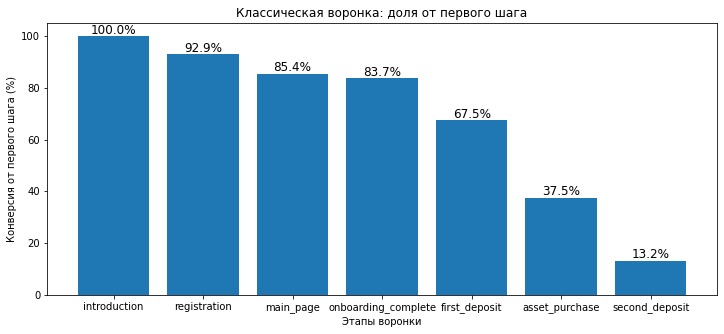

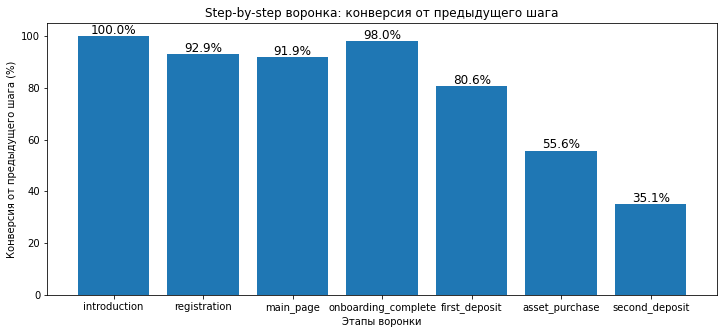

In [24]:
steps = funnel_df['step'][1:]
conversions_classic = funnel_df['conversion_from_first_%'][1:]
conversions_by_step = funnel_df['conversion_from_previous_%'][1:]

# Визуализируем данные классической воронки
plt.figure(figsize=(12, 5))

# Строим barplot
plt.bar(steps,
    conversions_classic)

# Перебираем в цикле значения конверсии, которые мы только что отобразили
for index, value in enumerate(conversions_classic):
    # Для каждого значения добавляем текст на график
    
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontsize=12, color='black')

plt.title('Классическая воронка: доля от первого шага')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')

# Визуализируем данные воронки step-by-step
plt.figure(figsize=(12, 5))

# Строим barplot
plt.bar(steps, 
        conversions_by_step)

# Перебираем в цикле значения конверсии, которые мы только что отобразили
for index, value in enumerate(conversions_by_step):
    # Для каждого значения добавляем текст на график
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontsize=12, color='black')

plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')

plt.show()

- Анализ воронки показывает, что пользовательский путь стабилен до завершения онбординга, но значительные потери происходят на этапе первого депозита, покупки активов и, особенно, на шаге пополнения брокерского счёта во второй раз. Эти шаги являются ключевыми для дальнейшей монетизации и требуют внимания продукта и маркетинга (например, улучшения интерфейса пополнения, подсказок по инвестированию и образовательного контента).

- Рассмотрим также воронку конверсии по регионам и платформам.

In [25]:
# Создадим функцию для подсчёта воронки
def funnel_by_segment(df, segment_col, segment_value, steps):
    df_seg = df[df[segment_col] == segment_value]
    
    counts = (
        df_seg[df_seg['event_name'].isin(steps)]
        .groupby('event_name')['user_id']
        .nunique()
        .reindex(steps)
    )
    
    funnel = pd.DataFrame({
        'users': counts.values
    }, index=steps)
    
    funnel['classic'] = round(funnel['users'] / funnel['users'].iloc[0] * 100, 1)
    funnel['step'] = round(funnel['users'] / funnel['users'].shift(1) * 100, 1)
    
    return funnel

In [26]:
# Построим воронки конверсии по регионам пользователей
countries = df_hist['country_code'].unique()

# Создаём пустые DataFrame для хранения результатов
classic_country_hist = pd.DataFrame()
step_country_hist = pd.DataFrame()

# Считаем воронку для каждой страны
for country in countries:
    funnel = funnel_by_segment(df_hist, 'country_code', country, funnel_steps)
    classic_country_hist[country] = funnel['classic']
    step_country_hist[country] = funnel['step']

# Обрезаем первый шаг
classic_country_hist = classic_country_hist.round(1).iloc[1:]
step_country_hist = step_country_hist.round(1).iloc[1:]

# Собираем итоговую таблицу
country_funnel_hist = pd.DataFrame(index=classic_country_hist.index)

for country in classic_country_hist.columns:
    country_funnel_hist[f'{country}_classic'] = classic_country_hist[country]
    country_funnel_hist[f'{country}_step'] = step_country_hist[country]

country_funnel_hist = country_funnel_hist.round(1)

display(country_funnel_hist)

,BR_classic,BR_step,AR_classic,AR_step,CO_classic,CO_step,MX_classic,MX_step
introduction,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
registration,92.8,92.8,93.4,93.4,92.7,92.7,93.0,93.0
main_page,85.2,91.8,86.5,92.6,85.4,92.1,84.9,91.3
onboarding_complete,83.5,98.1,84.7,97.9,83.6,98.0,83.2,98.0
first_deposit,67.4,80.7,67.7,79.9,67.6,80.8,67.2,80.8
asset_purchase,38.0,56.3,37.5,55.4,36.8,54.4,37.7,56.0
second_deposit,12.9,34.0,13.6,36.2,12.9,35.1,13.4,35.6


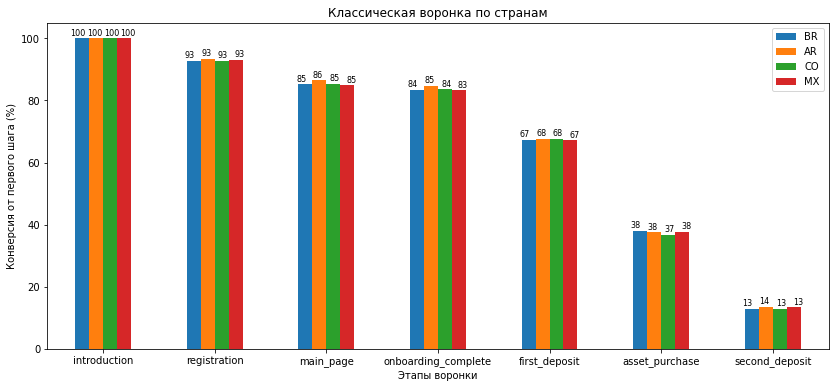

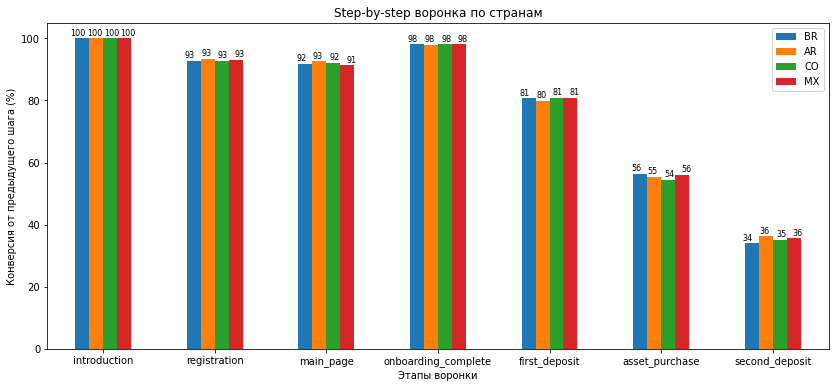

In [27]:
# Визуализируем данные классической воронки
classic_country_hist.plot(
    kind='bar',
    figsize=(14, 6),
    rot=0
)

# Подписи значений
for col_index, country in enumerate(classic_country_hist.columns):
    for i, val in enumerate(classic_country_hist[country]):
        plt.text(i + (col_index - 1.5) * 0.15, val + 1, f'{val:.0f}', ha='center', fontsize=8, color='black')

plt.title('Классическая воронка по странам')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от первого шага (%)')

# Визуализируем данные воронки step-by-step
step_country_hist.plot(
    kind='bar',
    figsize=(14, 6),
    rot=0
)

# Подписи значений
for col_index, country in enumerate(step_country_hist.columns):
    for i, val in enumerate(step_country_hist[country]):
        plt.text(i + (col_index - 1.5) * 0.15, val + 1, f'{val:.0f}', ha='center', fontsize=8, color='black')

plt.title('Step-by-step воронка по странам')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.show()

- Графики классической и пошаговой воронок показывают однородность поведения пользователей во всех четырёх регионах (Бразилия, Аргентина, Колумбия, Мексика).

In [28]:
# Построим воронки конверсии по платформам пользователей
platforms = df_hist['platform'].unique()

# Создаём пустые DataFrame для хранения результатов
classic_platform_hist = pd.DataFrame()
step_platform_hist = pd.DataFrame()

# Считаем воронку для каждой платформы
for platform in platforms:
    funnel = funnel_by_segment(df_hist, 'platform', platform, funnel_steps)
    classic_platform_hist[platform] = funnel['classic']
    step_platform_hist[platform] = funnel['step']

# Обрезаем первый шаг 
classic_platform_hist = classic_platform_hist.round(1).iloc[1:]
step_platform_hist = step_platform_hist.round(1).iloc[1:]

# Собираем итоговую таблицу для удобного сравнения
platform_funnel_hist = pd.DataFrame(index=classic_platform_hist.index)
for platform in classic_platform_hist.columns:
    platform_funnel_hist[f'{platform}_classic'] = classic_platform_hist[platform]
    platform_funnel_hist[f'{platform}_step'] = step_platform_hist[platform]

platform_funnel_hist = platform_funnel_hist.round(1)
display(platform_funnel_hist)

,mobile_classic,mobile_step,web_classic,web_step
introduction,100.0,100.0,100.0,100.0
registration,92.9,92.9,93.0,93.0
main_page,85.2,91.7,85.8,92.3
onboarding_complete,83.5,98.0,84.2,98.1
first_deposit,67.4,80.7,67.7,80.5
asset_purchase,37.4,55.6,37.7,55.7
second_deposit,13.2,35.4,13.0,34.5


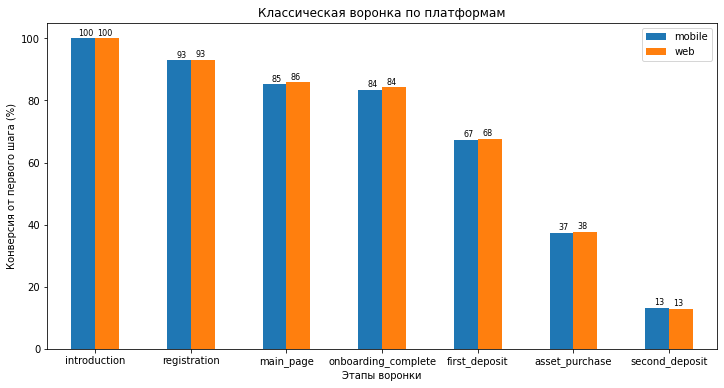

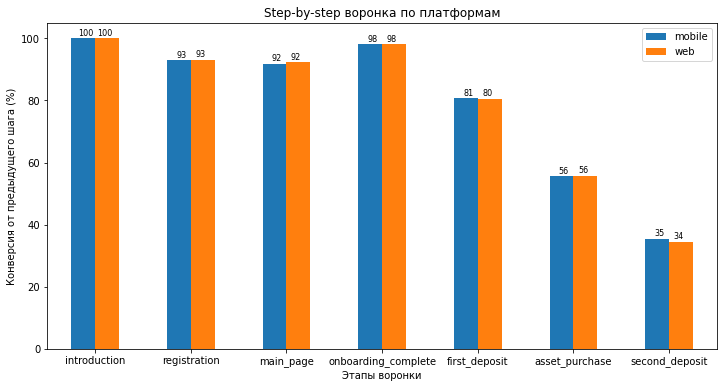

In [29]:
# Визуализируем данные классической воронки по платформам
classic_platform_hist.plot(
    kind='bar',
    figsize=(12, 6),
    rot=0
)

# Добавляем подписи значений
for col_index, platform in enumerate(classic_platform_hist.columns):
    for i, val in enumerate(classic_platform_hist[platform]):
        plt.text(i + (col_index - 0.5) * 0.2, val + 1, f'{val:.0f}', ha='center', fontsize=8, color='black')

plt.title('Классическая воронка по платформам')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от первого шага (%)')
plt.show()

# Визуализируем данные step-by-step
step_platform_hist.plot(
    kind='bar',
    figsize=(12, 6),
    rot=0
)

# Добавляем подписи значений
for col_index, platform in enumerate(step_platform_hist.columns):
    for i, val in enumerate(step_platform_hist[platform]):
        plt.text(i + (col_index - 0.5) * 0.2, val + 1, f'{val:.0f}', ha='center', fontsize=8, color='black')

plt.title('Step-by-step воронка по платформам')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.show()

- Анализ воронки в разрезе платформ показывает на синхронность поведения пользователей.

Результаты в разрезе стран и платформ подтверждают, что проблема низкой вовлеченности в повторные депозиты является системной. Она не привязана к конкретному региону или типу устройства, а значит, решение в виде образовательного онбординга теоретически должно сработать универсально для всей аудитории SollmaFin.

<a class="anchor" id="impact-of-asset-risk-level-on-second-deposit-conversion"></a>
### 2.3 Влияние уровня риска актива на открытие второго депозита
- Изучим, как уровень риска первого актива влияет на конверсию во второй депозит. Сравним пользовательский путь после покупки первого актива с разным уровнем риска. Для этого построим и визуализируем три воронки step-by-step: для новых пользователей, которые приобрели первый дипозит с низким, среднем и высоким риском.  

In [30]:
# Найдем первую покупку актива пользователя
first_asset = (
    df_hist[df_hist['event_name'] == 'asset_purchase']
    .sort_values('event_ts')
    .groupby('user_id')
    .first()
    .reset_index()
)

# Разделим данные по степень риска первого купленного депозита
low_users = first_asset[first_asset['risk_level'] == 'low']['user_id']
medium_users = first_asset[first_asset['risk_level'] == 'medium']['user_id']
high_users = first_asset[first_asset['risk_level'] == 'high']['user_id']

# создадим функцию для построения step-by-step воронки
def funnel(df, users, steps):

    # Фильтруем датасет, оставляя только нужные шаги воронки 
    data = df[(df['user_id'].isin(users)) & (df['event_name'].isin(steps))]

    # Считаем количество клиентов на каждом шаге
    counts = (
        data
        .groupby('event_name')['user_id']
        .nunique()
        .reindex(steps)
    )

    # Считаем конверсию 
    return round(counts / counts.shift(1) * 100, 2)

# Cтроим воронки
low_funnel = funnel(df_hist, low_users, funnel_steps)
medium_funnel = funnel(df_hist, medium_users, funnel_steps)
high_funnel = funnel(df_hist, high_users, funnel_steps)

# Соберём через словарь данные в датафрейм и исключим все шаги до покупки актива
funnal_compare = pd.DataFrame({
    'step': funnel_steps[-2:],
    'low': low_funnel[-2:].values,
    'medium': medium_funnel[-2:].values,
    'high': high_funnel[-2:].values
})

display(funnal_compare)

,step,low,medium,high
0,asset_purchase,100.00,100.00,100.00
1,second_deposit,46.41,42.97,26.36


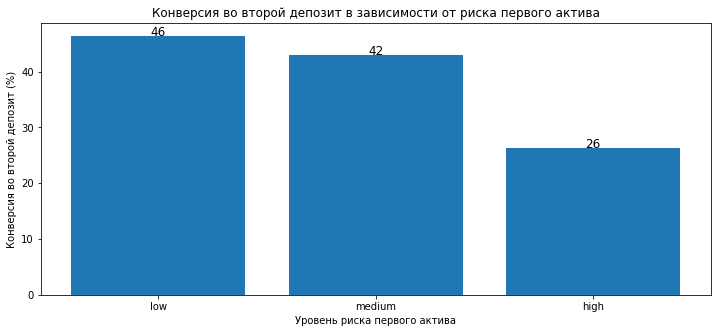

In [31]:
# Построим график 
second_deposit = funnal_compare[funnal_compare['step'] == 'second_deposit']
risk_levels = ['low', 'medium', 'high']
values = second_deposit[risk_levels].iloc[0]

plt.figure(figsize=(12, 5))
bars_deposit = plt.bar(risk_levels, values)

# Перебираем в цикле значения, которые мы только что отобразили
for bar in bars_deposit:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', fontsize=12)

plt.title('Конверсия во второй депозит в зависимости от риска первого актива')
plt.xlabel('Уровень риска первого актива')
plt.ylabel('Конверсия во второй депозит (%)')
plt.show()

- До этапа покупки актива конверсия во всех группах составляет 100%, так как в анализ включены только пользователи, уже совершившие первую покупку.

- Пользователи, выбравшие высокорисковые активы, значительно реже возвращаются и открывают второй депозит по сравнению с пользователями, начавшими с активов низкого и среднего риска.
Это подтверждает гипотезу о том, что покупка высокорисковых активов без достаточного понимания рисков может приводить к негативному опыту и снижению удержания.

<a class="anchor" id="historical-monetization-metric-analysis"></a>
### 2.4 Анализ ключевой метрики на исторических данных
- На исторических данных рассчитаем значение ключевой метрики — средней суммы всех депозитов на одного пользователя. Учитываем всех пользователей, которые взаимодействовали с сервисом. Это позволит зафиксировать базовый уровень монетизации.

In [32]:
# Посчитаем сумму всех депозитов по каждому пользователю
users_deposits = (
    df_hist[df_hist['event_name'].isin(['first_deposit', 'second_deposit'])]
    .groupby('user_id')
    .agg(total_deposit = ('amount', 'sum'))
    .reset_index()
)

# Оставим всех пользователей, которые взаимодействовали с сервисом
all_users = df_hist[['user_id']].drop_duplicates()

# Объединяем в общий датафрейм с учетом неплатящих пользователей
df_monetization = (
    all_users
    .merge(users_deposits, how='left', on='user_id')
    .fillna(0)
)

# Рассчитаем среднюю сумму всех депозитов на одного пользователя
avg_deposit_per_user = round(df_monetization['total_deposit'].mean(), 2)

# Рассчитаем стандартное отклонение
std_deposit_per_user = round(df_monetization['total_deposit'].std(), 2)

print(f'Cреднеe суммы всех депозитов на одного пользователя = {avg_deposit_per_user}.')
print(f'Cтандартное отклонение суммы депозитов на одного пользователя = {std_deposit_per_user}.')

Cреднеe суммы всех депозитов на одного пользователя = 91.56.
Cтандартное отклонение суммы депозитов на одного пользователя = 80.39.


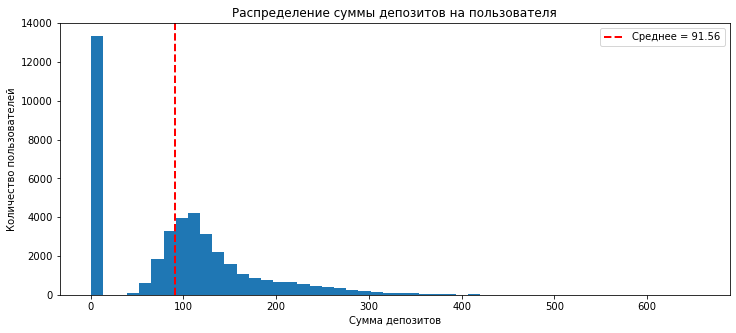

In [68]:
# Построим график 
plt.figure(figsize=(12, 5))
plt.hist(df_monetization['total_deposit'], bins=50)
plt.axvline(avg_deposit_per_user, color='red', linestyle='dashed', linewidth=2, label=f'Среднее = {avg_deposit_per_user}')

plt.title('Распределение суммы депозитов на пользователя')
plt.xlabel('Сумма депозитов')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

- Дополнительно проверим влияние выбросов на метрику. Для этого отфильтруем экстремальные значения выше 99-го перцентиля и сравним результаты до и после фильтрации.

In [34]:
# Рассчитаем 99-й перцентиль
percentile_99 = df_monetization['total_deposit'].quantile(0.99)

# Отфильтруем экстремальные значения
df_monetization_filtered = df_monetization[
    df_monetization['total_deposit'] <= percentile_99
]

# Повторно рассчитаем метрики после фильтрации выбросов
avg_filtered = round(
    df_monetization_filtered['total_deposit'].mean(), 2
)

std_filtered = round(
    df_monetization_filtered['total_deposit'].std(), 2
)

print(f'Среднее после фильтрации = {avg_filtered}')
print(f'Std после фильтрации = {std_filtered}')

Среднее после фильтрации = 88.88
Std после фильтрации = 76.09


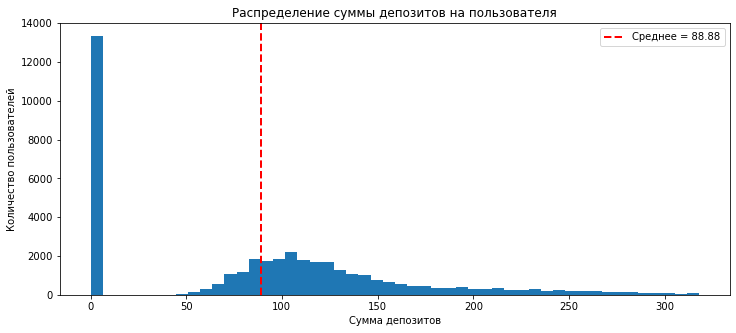

In [67]:
# Построим распределение после фильтрации выбросов
plt.figure(figsize=(12, 5))
plt.hist(df_monetization_filtered['total_deposit'], bins=50)
plt.axvline(avg_filtered, color='red', linestyle='dashed', linewidth=2, label=f'Среднее = {avg_filtered}')

plt.title('Распределение суммы депозитов на пользователя')
plt.xlabel('Сумма депозитов')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

- Значительная доля пользователей имеет нулевую или очень маленькую сумму депозитов, что соответствует большому чилу неплатящих или сделавших только минимальный первый депозит. 


- Основная масса платящих пользователей с суммой 50-150. Распределение неоднородное, наблюдается длинный правый хвост, что означает, что есть небольшая доля пользователей, которые вносят значительно большие суммы, что также существенно влияет на среднее значение.


- До фильтрации выбросов средняя сумма депозитов на пользователя составляла 91.56, а стандартное отклонение - 80.39, что указывало на высокий разброс значений и чувствительность метрики к экстремальным наблюдениям.


- После фильтрации значений выше 99-го перцентиля средняя сумма депозитов снизилась до 88.88, а стандартное отклонение - до 76.09. Это подтверждает, что часть пользователей с очень крупными депозитами заметно влияет на итоговые значения метрик.


- Несмотря на снижение разброса после фильтрации, распределение всё ещё остаётся асимметричным, поэтому при анализе результатов A/B-эксперимента важно учитывать влияние выбросов и дополнительно использовать устойчивые методы оценки, например bootstrap-анализ и исследование перцентилей распределения.

**Вывод:** 

- Анализ динамики привлечения новых пользователей показал, что приток аудитории в приложение стабильный и равномерный.
- Основная аудитория приходит из Бразилии и Мексики, при этом большинство пользователей предпочитает мобильную платформу.
- Пользовательский путь до завершения онбординга проходит без существенных потерь, однако заметное снижение конверсии начинается на этапах, связанных с денежными действиями - первым депозитом, покупкой активов и особенно вторым депозитом. 
- Пользователи, начавшие с высокорисковых активов, значительно реже совершают второй депозит, что может указывать о негативном первом инвестиционном опыте и снижении доверия к продукту.
- Базовый уровень монетизации на исторических данных составляет 91.56. После фильтрации экстремальных значений выше 99-го перцентиля среднее значение снижается до 88.88, что подтверждает влияние выбросов на ключевую метрику. Распределение депозитов остаётся асимметричным: значительная часть пользователей не вносит депозиты или ограничивается небольшими суммами, тогда как небольшая группа пользователей формирует длинный правый хвост распределения.

## 3 Исследование результатов А/В эксперимента
Загрузим данные с результатами эксперимента (датасет `/datasets/pa_sollmafin_abt.csv `). Проверим корректность данных и проведем предобработку. Зафиксируйем основную информацию о данных и предобработке в кратком промежуточном выводе.

In [35]:
# Выгружаем данные A/B-эксперимента
df_abt = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_abt.csv', 
                     parse_dates=['first_ts', 'first_dt', 'event_ts'])
 
display(df_abt.head())
print()
df_abt.info()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


Данные представлены корректными типами данных.
- Посмотрим какое количество уникальных пользователей и какие страны, платформы, названия событий, А/В-эксперименты, пользовательские группы экспериментво, типы активов и уровни риска  представлены в датасете.

In [36]:
# Выводим количество уникальных значений в колонке user_id и значения в country_code, platform, event_name, ab_test, group, asset, risk_level
print(f"Количество уникальных значений user_id - {df_abt['user_id'].nunique()}.") 

summary_abt = (
    df_abt[['country_code', 'platform', 'event_name', 'ab_test', 'group', 'asset', 'risk_level']]
    .apply(lambda x: ", ".join(sorted(x.dropna().unique())))
    .reset_index()
)

summary_abt.columns = ['column', 'unique_values']
pd.set_option('display.max_colwidth', None)
display(summary_abt)

Количество уникальных значений user_id - 9415.


,column,unique_values
0,country_code,"AR, BR, CO, MX"
1,platform,"mobile, web"
2,event_name,"asset_purchase, first_deposit, install / open_web, introduction, main_page, onboarding_complete, registration, second_deposit"
3,ab_test,onboarding_test
4,group,"control, test"
5,asset,"crypto, option, stock"
6,risk_level,"high, low, medium"


В датасете представлены все ключевые сущности пользовательского пути: страны, платформы, события воронки, группы A/B-эксперимента, а также характеристики инвестиционных активов.

- Проверим интервал дат первого появления пользователей, привлечённых в период со 2 по 15 июня 2025 года включительно.

In [37]:
# Проверим интервал дат событий
start_date = df_abt['first_dt'].min()
end_date = df_abt['first_dt'].max()

print(f'Период данных: с {start_date} по {end_date}')

Период данных: с 2025-06-02 00:00:00 по 2025-06-15 00:00:00


- Проверим интервал дат событий.

In [38]:
# Проверим интервал дат событий
start_date = df_abt['event_ts'].min()
end_date = df_abt['event_ts'].max()

print(f'Период данных: с {start_date} по {end_date}')

Период данных: с 2025-06-02 00:27:50 по 2025-06-22 13:37:05


События выходят за пределы периода привлечения пользователей, так как отражают дальнейшее поведение пользователей после регистрации, что соответствует логике A/B-эксперимента.

- Проверим данные на наличие дубликатов.

In [39]:
# Количество полных дубликатов
full_duplicates_abt = df_abt.duplicated().sum()
print(f'Количество полных дубликатов строк: {full_duplicates_abt}')

Количество полных дубликатов строк: 0


In [40]:
# Проверим дубликаты событий внутри одного события
event_duplicates_abt = df_abt.duplicated(subset=['user_id', 'event_ts', 'event_name']).sum()

print(f'Неявные дубликаты событий: {event_duplicates_abt}')

Неявные дубликаты событий: 0


In [41]:
# Проверим дубликаты событий первого депозита
first_deposit_duplicates_abt = (
    df_abt[df_abt['event_name'] == 'first_deposit']
    .duplicated(subset=['user_id'])
    .sum()
)

print(f'Неявные дубликаты событий: {first_deposit_duplicates_abt}')

Неявные дубликаты событий: 0


In [42]:
# Проверим дубликаты событий второго депозита
second_deposit_duplicates_abt = (
    df_abt[df_abt['event_name'] == 'second_deposit']
    .duplicated(subset=['user_id'])
    .sum()
)

print(f'Неявные дубликаты событий: {second_deposit_duplicates_abt}')

Неявные дубликаты событий: 0


In [43]:
# Проверим дубликаты событий покупки активов
asset_purchase_duplicates_abt = (
    df_abt[df_abt['event_name'] == 'asset_purchase']
    .duplicated(subset=['user_id', 'event_ts', 'asset', 'amount'])
    .sum()
)

print(f'Неявные дубликаты событий: {asset_purchase_duplicates_abt}')

Неявные дубликаты событий: 0


In [44]:
# Проверим дубликаты уникальных событий
single_events = [
    'install / open_web',
    'introduction',
    'registration',
    'onboarding_complete'
]

single_events_duplicates_abt = (
    df_abt[df_abt['event_name'].isin(single_events)]
    .duplicated(subset=['user_id', 'event_name'])
    .sum()
)

print(f'Неявные дубликаты событий: {single_events_duplicates_abt}')

Неявные дубликаты событий: 0


- В рамках этапа предобработки были загружены и изучены данные А/В-эксперимента - все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей. 

Датасет `df_abt` содержит 12 столбцов и 54 805 строк с данными. 

После первичного анализа данных можно сделать следующие выводы:
- Большинство столбцов представлены корректными типами данных. 
- Столбцы `first_ts`, `first_dt`, `event_ts` успешно преобразованы в формат `datetime`, что позволяет анализировать пользовательское поведение во времени.
- Три столбца содержат пропуски: `amount`, `asset`, `risk_level`. Наличие пропусков в данных столбцах обусловлено тем, что данные заполняются только для событий покупки активов и отсутствуют для технических и навигационных событий. Дополнительной обработки пропусков не требуется.
- В датасете представлены 9 415 уникальных зарегистрированных пользователя (`user_id`).
- Полные дубликаты строк отсутствуют.
- Неявные дубликаты событий не выявлены.

Данные имеют хорошее качество и не содержат критических ошибок, пропусков или дубликатов, искажающих бизнес-логику.
Датасет полностью готов для дальнейшего анализа.

<a class="anchor" id="experiment-audience-analysis"></a>
### Задача 3.1 Анализ аудитории эксперимента 
- Проверим корректность распределения новых пользователей по группам А/В-эксперимента. 
- Построим графики и сформулируем промежуточный вывод. 

Для начала проверим датасет на наличие пользователей, которые попали одновременно в контрольную и тестовую группы эксперимента.

In [45]:
# Считаем количество уникальных групп на user_id
flawed_users = df_abt.groupby('user_id')['group'].nunique().reset_index()

# Фильтруем клиентов у которых больше 1 группы
flawed_users = flawed_users[flawed_users['group'] > 1]

print(f'Количество пользователей, попавших сразу в две группы: {len(flawed_users)}.')

Количество пользователей, попавших сразу в две группы: 0.


In [46]:
# Считаем количество уникальных пользователей в каждой группе А/В-теста
groups = df_abt.groupby('group').agg(users=('user_id', 'nunique')).reset_index()

# Рассчитаем долю каждой группы
groups['share'] = round(groups['users'] / groups['users'].sum() * 100, 2)

display(groups)

,group,users,share
0,control,4847,51.48
1,test,4568,48.52


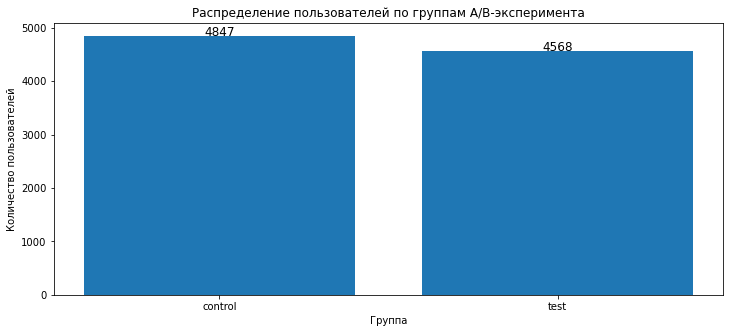

In [47]:
# Построим график 
plt.figure(figsize=(12, 5))
bars_groups = plt.bar(groups['group'], groups['users'])

# Перебираем в цикле значения, которые мы только что отобразили
for bar in bars_groups:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', fontsize=12)

plt.title('Распределение пользователей по группам A/B-эксперимента')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.show()

- Пользователи распределены между контрольной и тестовой группами равномерно: 51,48% пользователей относятся к контрольной группе и 48,52% - к тестовой. Пересечений пользователей между группами не выявлено.
Таким образом, аудитория A/B-эксперимента сформирована корректно, группы сопоставимы по размеру, что позволяет переходить к сравнению пользовательского поведения и ключевых метрик без риска систематических искажений.

<a class="anchor" id="event-funnel-comparison"></a>
### Задача 3.2 Сравнение воронок событий
- Сравним пользовательский путь новых пользователей в тестовой и контрольной группах.
- Построем классическую и последовательную воронки, выполним визуализацию и сделаем промежуточный вывод. 

In [48]:
# Разделим данные по группам
control_df = df_abt[df_abt['group']=='control']
test_df = df_abt[df_abt['group']=='test']

# Фильтруем датасет, оставляя только нужные шаги воронки для control
counts_control = control_df[control_df['event_name'].isin(funnel_steps)]

# Считаем количество пользователей на каждом шаге
counts_control_agg = (
    counts_control
    .groupby('event_name')['user_id']
    .nunique()
    .reindex(funnel_steps)
)

# Считаем конверсию для control и округляем значение до 1 знака после запятой
control_funnel_classic = round(counts_control_agg / counts_control_agg[0] * 100, 1)
control_funnel_step = round(counts_control_agg / counts_control_agg.shift(1) * 100, 1)

# Повторяем шаги для test
counts_test = test_df[test_df['event_name'].isin(funnel_steps)]
counts_test_agg = (
    counts_test
    .groupby('event_name')['user_id']
    .nunique()
    .reindex(funnel_steps)
)

test_funnel_classic = round(counts_test_agg / counts_test_agg[0] * 100, 1)
test_funnel_step = round(counts_test_agg / counts_test_agg.shift(1) * 100, 1)

# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
classic_funnel_compare = pd.DataFrame({
    'step': funnel_steps[1:],
    'control': control_funnel_classic[1:].values,
    'test': test_funnel_classic[1:].values
})

step_funnel_compare = pd.DataFrame({
   'step': funnel_steps[1:],
   'control': control_funnel_step[1:].values,
   'test': test_funnel_step[1:].values
})

print('Классическая воронка:')
display(classic_funnel_compare)
print()
print('Step-by-step воронка:')
display(step_funnel_compare)

Классическая воронка:


,step,control,test
0,introduction,100.0,100.0
1,registration,93.1,93.4
2,main_page,85.8,85.8
3,onboarding_complete,83.8,75.8
4,first_deposit,66.6,65.4
5,asset_purchase,36.6,43.3
6,second_deposit,13.5,21.3



Step-by-step воронка:


,step,control,test
0,introduction,100.0,100.0
1,registration,93.1,93.4
2,main_page,92.2,91.9
3,onboarding_complete,97.6,88.3
4,first_deposit,79.4,86.3
5,asset_purchase,54.9,66.2
6,second_deposit,36.9,49.3


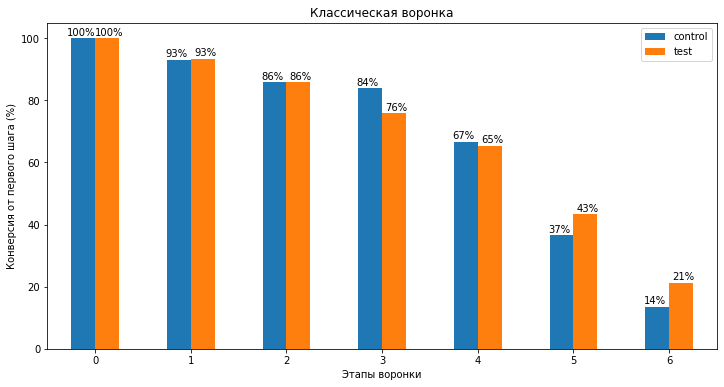

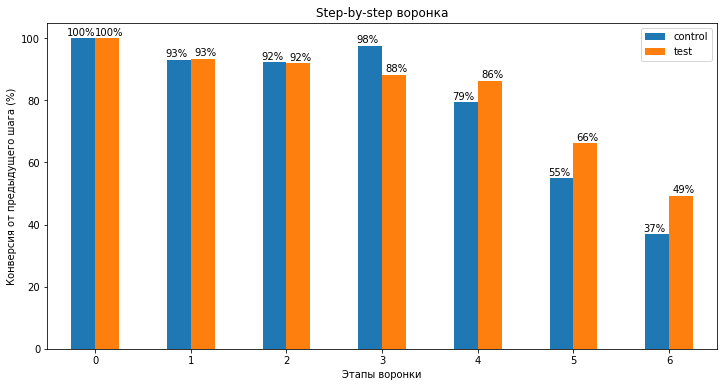

In [49]:
# Визуализируем данные классической воронки

# Строим столбчатую диаграмму 
classic_plot_df = classic_funnel_compare[['control', 'test']].plot(
    kind='bar',
    figsize=(12, 6),
    legend=True, 
    rot=0
)

# Подписи для control
for index, value in enumerate(classic_funnel_compare['control']):
    # Для каждого значения добавляем текст на график
    plt.text(index - 0.15, value + 1, f'{value:.0f}%', ha='center', fontsize=10, color='black')

# Подписи для test
for index, value in enumerate(classic_funnel_compare['test']):
    # Для каждого значения добавляем текст на график
    plt.text(index + 0.15, value + 1, f'{value:.0f}%', ha='center', fontsize=10, color='black')    
    
# Настраиваем оформление графика
plt.title('Классическая воронка')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от первого шага (%)')


# Визуализируем данные воронки step-by-step

# Строим столбчатую диаграмму 
step_plot_df = step_funnel_compare[['control', 'test']].plot(
    kind='bar',
    figsize=(12, 6),
    legend=True, 
    rot=0
)

# Подписи для control
for index, value in enumerate(step_funnel_compare['control']):
    # Для каждого значения добавляем текст на график
    plt.text(index - 0.15, value + 1, f'{value:.0f}%', ha='center', fontsize=10, color='black')

# Подписи для test
for index, value in enumerate(step_funnel_compare['test']):
    # Для каждого значения добавляем текст на график
    plt.text(index + 0.15, value + 1, f'{value:.0f}%', ha='center', fontsize=10, color='black')    
    
# Настраиваем оформление графика
plt.title('Step-by-step воронка')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.show()

- Пользовательские воронки контрольной и тестовой групп совпадают на ранних этапах: до регистрации и перехода на главный экран различия минимальны.


- На этапе завершения онбординга тестовая группа демонстрирует более низкую конверсию по сравнению с контрольной, что может указывать на усложнение или ухудшение восприятия обновлённого онбординга.


- При этом на этапах, связанных с денежными действиями, тестовая группа показывает лучшие результаты. Конверсия в покупку активов и особенно во второй депозит в тесте выше как в классической, так и в последовательной воронке.


- Таким образом, новый онбординг может снижать вовлечённость части пользователей на этапе завершения обучения, но при этом положительно влияет на поведение пользователей, дошедших до финансовых действий.

<a class="anchor" id="impact-of-the-new-feature-on-second-deposit-conversion-by-asset-risk-level"></a>
### Задача 3.3 Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива
- Проанализируем, как категория риска купленного актива влияет на вероятность открытия второго депозита в тестовой и контрольной группах. 
- Сравним результаты и оценим, есть ли статистически значимая разница между группами. 

In [50]:
# Найдем первую покупку актива пользователя
first_asset_abt = (
    df_abt[df_abt['event_name'] == 'asset_purchase']
    .sort_values('event_ts')
    .groupby(['group','user_id'])
    .first()
    .reset_index()
)

# Найдем пользователей со вторым депозитом
second_deposit_users = df_abt[df_abt['event_name'] == 'second_deposit']['user_id'].unique()

# создадим функцию для построения конверсии
def second_deposit_conv(users):

    return round(users['user_id'].isin(second_deposit_users).mean() * 100, 2)

# Считаем конверсии по риску и группе
results = []

# Разделяем пользователей по уровню риска и группе
groups = ['control', 'test']
risks = ['low', 'medium', 'high']

for g in groups:
    for r in risks:
        users = first_asset_abt[
            (first_asset_abt['group'] == g) &
            (first_asset_abt['risk_level'] == r)
            ]
        
        conversion = second_deposit_conv(users)
        
        results.append({
            'risk': r,
            'group': g,
            'second_deposit_conversion_%': conversion
        })

# Собираем в датафрейм
conversion_df = pd.DataFrame(results)

# Делаем таблицу
conversion_pivot = conversion_df.pivot(
    index='risk',
    columns='group',
    values='second_deposit_conversion_%'
)

display(conversion_pivot)

group,control,test
risk,,
high,27.66,46.00
low,49.82,57.46
medium,44.54,47.04


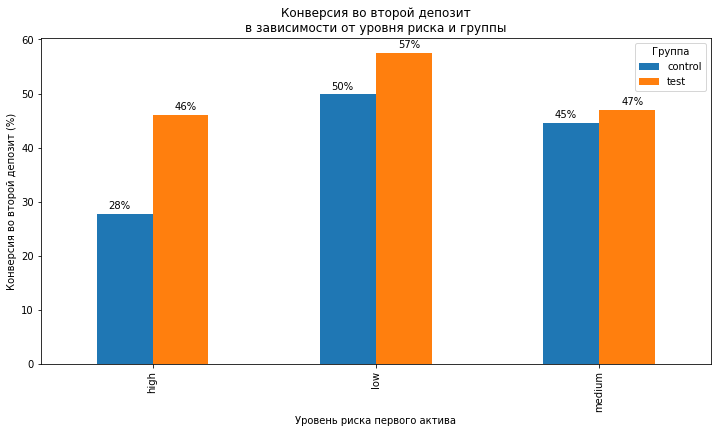

In [51]:
# Визуализируем конверсию во второй депозит по уровню риска и группе
plot_df = conversion_pivot[['control', 'test']].plot(
    kind='bar',
    figsize=(12, 6),
    legend=True
)

# Подписи для control
for index, value in enumerate(conversion_pivot['control']):
    # Для каждого значения добавляем текст на график
    plt.text(index - 0.15, value + 1, f'{value:.0f}%', ha='center', fontsize=10, color='black')

# Подписи для test
for index, value in enumerate(conversion_pivot['test']):
    # Для каждого значения добавляем текст на график
    plt.text(index + 0.15, value + 1, f'{value:.0f}%', ha='center', fontsize=10, color='black')    
    
# Настраиваем оформление графика
plt.title('Конверсия во второй депозит\nв зависимости от уровня риска и группы')
plt.xlabel('Уровень риска первого актива')
plt.ylabel('Конверсия во второй депозит (%)')
plt.legend(title='Группа')
plt.show()

- Во всех категориях риска конверсия во второй депозит в тестовой группе выше, чем в контрольной.
- Наиболее выраженный эффект наблюдается для пользователей, начавших с высокорисковых активов: в тестовой группе их конверсия во второй депозит почти в 1.7 раза выше.
- Это может свидетельствовать о том, что новый онбординг лучше подготавливает пользователей к рисковым инвестициям и снижает негативный эффект первого опыта.

Для оценки статистической значимости различий в конверсии во второй депозит между тестовой и контрольной группами внутри каждого уровня риска применим z-test для сравнения долей.

**Нулевая гипотеза (H0):**
Конверсия во второй депозит в тестовой и контрольной группах не различается.

**Альтернативная гипотеза (H1):**
Конверсия во второй депозит в тестовой группе больше, чем в контрольной.

In [52]:
# Функция проверки гипотезы через z-test
def ztest_second_deposit(df, first_asset_df, risk, alpha=0.05):
    # Фильтруем пользователей нужного уровня риска
    users = first_asset_df[first_asset_df['risk_level'] == risk][['user_id', 'group']]
    
    # Флаг - был ли второй депозит
    second_dep = (
        df[df['event_name'] == 'second_deposit']
        .groupby('user_id')['event_name']
        .count()
        .reset_index()
    )
    
    second_dep['second_deposit_flag'] = 1
    
    data = users.merge(second_dep[['user_id', 'second_deposit_flag']], on='user_id', how='left')
    data['second_deposit_flag'] = data['second_deposit_flag'].fillna(0)
    
    # Pазмеры групп
    n_control = data[data['group'] == 'control'].shape[0]
    n_test = data[data['group'] == 'test'].shape[0]
    
    # Kоличество успехов
    m_control = data[(data['group'] == 'control') & (data['second_deposit_flag'] == 1)].shape[0]
    m_test = data[(data['group'] == 'test') & (data['second_deposit_flag'] == 1)].shape[0]
    
    # Доли успехов для каждой группы
    p_control = m_control / n_control
    p_test = m_test / n_test
    
    # Проверим предпосылку о достаточном количестве данных
    if ((p_control * n_control > 10) and ((1 - p_control)* n_control > 10) and
        (p_test * n_test > 10) and ((1 - p_test)* n_test > 10)): 
        print('\nПредпосылка о достаточном количестве данных выполняется!')
    else:
        print('\nПредпосылка о достаточном количестве данных НЕ выполняется!')
        return

    # Z-test
    stat_ztest, p_value_ztest = proportions_ztest(
        [m_test, m_control],
        [n_test, n_control],
        alternative='larger'
    )

    print(f'pvalue = {round(p_value_ztest, 4)}') 

    if p_value_ztest > alpha:
        print(f'Риск: {risk}, Нулевая гипотеза находит подтверждение! Конверсия не изменилась.')
    else:
        print(f'Риск: {risk}, Нулевая гипотеза не находит подтверждения! Конверсия выросла.')

for risk in ['low', 'medium', 'high']:
    ztest_second_deposit(df_abt, first_asset_abt, risk)


Предпосылка о достаточном количестве данных выполняется!
pvalue = 0.0195
Риск: low, Нулевая гипотеза не находит подтверждения! Конверсия выросла.

Предпосылка о достаточном количестве данных выполняется!
pvalue = 0.1803
Риск: medium, Нулевая гипотеза находит подтверждение! Конверсия не изменилась.

Предпосылка о достаточном количестве данных выполняется!
pvalue = 0.0
Риск: high, Нулевая гипотеза не находит подтверждения! Конверсия выросла.


- Новый онбординг демонстрирует положительную тенденцию к росту конверсии во второй депозит, особенно для пользователей с низким и высоким уровнем риска. 

- Для пользователей со средним уровнем риска статистически значимых изменений не зафиксировано.

<a class="anchor" id="ab-test-metrics-analysis"></a>
### Задача 3.4 Анализ метрик А/В-эксперимента 
Проанализируем такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики выведем: 
- значения в контрольной и тестовой группах, 
- абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

После этого проверим статистическую значимость различий метрик между группами эксперимента. 

Для ключевой метрики также изучим:
- накопленную динамику изменения по дням эксперимента для каждой группы, 
- стабильность p-value во время эксперимента.

Начнем с **ключевой метрики.**

In [53]:
# Посчитаем сумму всех депозитов по каждому пользователю
users_deposits_abt = (
    df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])]
    .groupby(['user_id', 'group'])
    .agg(total_deposit = ('amount', 'sum'))
    .reset_index()
)

# Оставим всех пользователей, которые взаимодействовали с сервисом
all_users_abt = df_abt[['user_id', 'group']].drop_duplicates()

# Объединяем в общий датафрейм с учетом неплатящих пользователей
df_monetization_abt = (
    all_users_abt
    .merge(users_deposits_abt, on=['user_id', 'group'], how='left')
    .fillna(0)
)

# Рассчитаем ключевую метрику
key_metric = (
    df_monetization_abt
    .groupby('group')
    .agg(avg_total_deposit = ('total_deposit', 'mean'))
    .reset_index()
)

control_avg = key_metric[key_metric['group'] == 'control']['avg_total_deposit'].values[0]
test_avg = key_metric[key_metric['group'] == 'test']['avg_total_deposit'].values[0]
                      
abs_change = test_avg - control_avg
rel_change = abs_change / control_avg * 100

print(f"Ключевая метрика - средняя сумма всех депозитов:")
print(f"Control: {control_avg:.2f}, Test: {test_avg:.2f}")
print(f"Абсолютное изменение: {abs_change:.2f}, Относительное изменение: {rel_change:.2f}%")

Ключевая метрика - средняя сумма всех депозитов:
Control: 90.24, Test: 92.46
Абсолютное изменение: 2.22, Относительное изменение: 2.46%


- Проверим статистическую значимость различий метрик между группами эксперимента. Для средних значений, когда данные по пользователям независимые и числовые, можно использовать t-test Уэлча.

**Нулевая гипотеза (H0):**
Средняя сумма депозитов одинаковая в тестовой и контрольной группах.

**Альтернативная гипотеза (H1):**
Средняя сумма всех депозитов на одного пользователя в тестовой и контрольной группах различается.

In [54]:
# Выборки по группам
control_deposits = df_monetization_abt[df_monetization_abt['group'] == 'control']['total_deposit']
test_deposits = df_monetization_abt[df_monetization_abt['group'] == 'test']['total_deposit']

# Т-test Уэлча
stat, p_value = ttest_ind(test_deposits, control_deposits, equal_var=False)

alpha = 0.05

print(f"Статистическая значимость различий:")
print(f"t-statistic = {stat:.3f}, p-value = {p_value:.4f}")

if p_value < alpha:
    print("Различие между группами статистически значимо!")
else:
    print("Различие между группами не является статистически значимым.")

Статистическая значимость различий:
t-statistic = 0.958, p-value = 0.3383
Различие между группами не является статистически значимым.


- Проанализируем накопленную динамику изменения по дням эксперимента для каждой группы.

In [55]:
# Количество пользователей в группах
users_cnt = (
    df_abt[['user_id', 'group']]
    .drop_duplicates()
    .groupby('group')['user_id']
    .nunique()
)

# Приведем время события ко дню
df_abt['event_dt'] = df_abt['event_ts'].dt.date

# Рассчитаем дневную сумму депозитов
daily_revenue = (
    df_abt[df_abt['event_name'].isin(['first_deposit', 'second_deposit'])]
    .groupby(['event_dt', 'group'])
    .agg(daily_revenue=('amount', 'sum'))
    .reset_index()
    .sort_values(['group', 'event_dt'])
)

# Рассчитаем кумулятивную среднюю сумму на пользователя
daily_revenue['cum_revenue'] = (
    daily_revenue
    .groupby('group')['daily_revenue']
    .cumsum()
)

daily_revenue['cum_avg_per_user'] = (
    daily_revenue
    .apply(lambda x: x['cum_revenue'] / users_cnt[x['group']], axis=1)
)

display(daily_revenue.head())

,event_dt,group,daily_revenue,cum_revenue,cum_avg_per_user
0,2025-06-02,control,472.0,472.0,0.097380
2,2025-06-03,control,14862.0,15334.0,3.163606
4,2025-06-04,control,25288.0,40622.0,8.380854
6,2025-06-05,control,25467.0,66089.0,13.635032
8,2025-06-06,control,29246.0,95335.0,19.668867


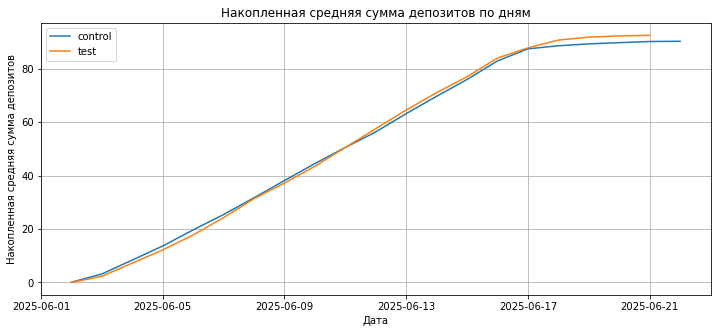

In [56]:
# График накопленной метрики
plt.figure(figsize=(12, 5))

for g in daily_revenue['group'].unique():
    data = daily_revenue[daily_revenue['group'] == g]
    plt.plot(data['event_dt'], data['cum_avg_per_user'], label=g)

plt.title('Накопленная средняя сумма депозитов по дням')
plt.xlabel('Дата')
plt.ylabel('Накопленная средняя сумма депозитов')
plt.legend()
plt.grid()
plt.show()

- Накопленная средняя сумма депозитов в контрольной и тестовой группах росла практически синхронно. Начиная с 17 июня, тестовая группа демонстрирует незначительное, но устойчивое преимущество по значению метрики. К концу эксперимента разница между группами сохраняется в пользу тестовой группы, однако визуально эффект выглядит небольшим, что согласуется с результатами статистического теста, показавшего отсутствие статистически значимых различий.


- Теперь изучим стабильность p-value во время эксперимента.

In [57]:
# Расчёт p-value по дням
pvalues = []

# Cоздадим список дней
dates = sorted(df_abt['event_dt'].unique())

for dt in dates:
    # Cобытия до текущего дня включительно
    df_cut = df_abt[
        (df_abt['event_dt'] <= dt)
        & (df_abt['event_name'].isin(['first_deposit', 'second_deposit']))
    ]
    
    # Cумма депозитов по каждому пользователю
    users_deposits_cut = (
        df_cut
        .groupby(['user_id', 'group'])
        .agg(total_deposit=('amount', 'sum'))
        .reset_index()
    )
    
    # Добавляем пользователей без депозитов
    df_monetization_cut = (
        all_users_abt
        .merge(users_deposits_cut, on=['user_id', 'group'], how='left')
        .fillna(0)
    )
    
    control = df_monetization_cut[df_monetization_cut['group'] == 'control']['total_deposit']
    
    test = df_monetization_cut[df_monetization_cut['group'] == 'test']['total_deposit']
    
    _, pval = ttest_ind(test, control, equal_var=False)
    
    pvalues.append({
        'event_dt': dt,
        'p_value': pval
    })

pvalues_df = pd.DataFrame(pvalues)

display(pvalues_df.head())

,event_dt,p_value
0,2025-06-02,0.071394
1,2025-06-03,0.038570
2,2025-06-04,0.092770
3,2025-06-05,0.096690
4,2025-06-06,0.080908


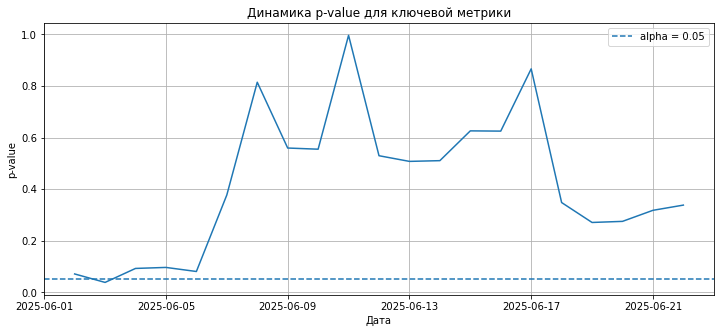

In [58]:
# График стабильности p-value
plt.figure(figsize=(12, 5))

plt.plot(pvalues_df['event_dt'], pvalues_df['p_value'])
plt.axhline(0.05, linestyle='--', label='alpha = 0.05')

plt.title('Динамика p-value для ключевой метрики')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.legend()
plt.grid()
plt.show()

- В начале эксперимента p-value демонстрирует заметные колебания, включая кратковременное пересечение уровня значимости 0.05, что связано с недостаточным объёмом данных. По мере накопления наблюдений p-value стабилизируется и на протяжении большей части эксперимента остаётся выше 0.05. Это подтверждает отсутствие статистически значимых различий по ключевой метрике и устойчивость итогового вывода независимо от момента остановки эксперимента.


- Теперь рассмотрим **барьерную метрику** - конверсию из регистрации в первый депозит.

In [59]:
# Пользователи с первым депозитом
first_deposit_users = (
    df_abt[df_abt['event_name'] == 'first_deposit']
    [['user_id', 'group']]
    .drop_duplicates()
)

# Добавляем флаг первого депозита
first_deposit_users['first_deposit_flag'] = 1

# Добавляем флаг первого депозита ко всем пользователям
first_dep_conv_df = (
    all_users_abt
    .merge(first_deposit_users, on=['user_id', 'group'], how='left')
    .fillna(0)
)

# Конверсия по группам
conv_first_deposit = (
    first_dep_conv_df
    .groupby('group')
    .agg(first_deposit_conversion=('first_deposit_flag', 'mean'))
    .reset_index()
)

control_conv = conv_first_deposit[conv_first_deposit['group'] == 'control']['first_deposit_conversion'].values[0]
test_conv = conv_first_deposit[conv_first_deposit['group'] == 'test']['first_deposit_conversion'].values[0]
                      
abs_change = test_conv - control_conv
rel_change = abs_change / control_conv * 100

print("Барьерная метрика — конверсия из регистрации в первый депозит:")
print(f"Control: {control_conv:.2f}, Test: {test_conv:.2f}")
print(f"Абсолютное изменение: {abs_change:.2f}, Относительное изменение: {rel_change:.2f}%")

Барьерная метрика — конверсия из регистрации в первый депозит:
Control: 0.67, Test: 0.65
Абсолютное изменение: -0.01, Относительное изменение: -1.81%


- Проверим статистическую значимость различий метрик между группами эксперимента. Для конверсий корректно использовать z-test для сравнения долей.

**Нулевая гипотеза (H0):**
Конверсия из регистрации в первый депозит одинаковая в тестовой и контрольной группах.

**Альтернативная гипотеза (H1):**
Конверсия из регистрации в первый депозит различается между группами.

In [60]:
# Размеры групп
n_control = first_dep_conv_df[first_dep_conv_df['group'] == 'control'].shape[0]
n_test = first_dep_conv_df[first_dep_conv_df['group'] == 'test'].shape[0]

# Количество успехов
m_control = first_dep_conv_df[(first_dep_conv_df['group'] == 'control') &
    (first_dep_conv_df['first_deposit_flag'] == 1)].shape[0]

m_test = first_dep_conv_df[(first_dep_conv_df['group'] == 'test') &
    (first_dep_conv_df['first_deposit_flag'] == 1)].shape[0]

# Z-test пропорций
stat, p_value = proportions_ztest(
    [m_control, m_test],
    [n_control, n_test],
    alternative='two-sided'
)

alpha = 0.05

print("Статистическая значимость различий:")
print(f"z-statistic = {stat:.3f}, p-value = {p_value:.4f}")

if p_value < alpha:
    print("Различие между группами статистически значимо!")
else:
    print("Различие между группами не является статистически значимым.")

Статистическая значимость различий:
z-statistic = 1.237, p-value = 0.2161
Различие между группами не является статистически значимым.


- Рассмотрим **вспомогательную метрику 1** - конверсию из первого депозита во второй.

In [61]:
# Найдем пользователей со вторым депозитом
second_deposit_users_abt = (
    df_abt[df_abt['event_name'] == 'second_deposit']
    [['user_id', 'group']]
    .drop_duplicates()
)

# Добавляем флаг второго депозита
second_deposit_users_abt['second_deposit_flag'] = 1

# Добавляем флаг первого депозита ко всем пользователям
second_dep_conv_df = (
    first_deposit_users[['user_id', 'group']]
    .merge(second_deposit_users_abt, on=['user_id', 'group'], how='left')
    .fillna(0)
)

# Конверсия по группам
conv_second_deposit = (
    second_dep_conv_df
    .groupby('group')
    .agg(second_deposit_conversion=('second_deposit_flag', 'mean'))
    .reset_index()
)

control_conv_sec_dep = conv_second_deposit[conv_second_deposit['group'] == 'control']['second_deposit_conversion'].values[0]
test_conv_sec_dep = conv_second_deposit[conv_second_deposit['group'] == 'test']['second_deposit_conversion'].values[0]
                      
abs_change_sec_dep = test_conv_sec_dep - control_conv_sec_dep
rel_change_sec_dep = abs_change_sec_dep / control_conv_sec_dep * 100

print("Вспомогательная метрика 1 — конверсия из первого депозита во второй:")
print(f"Control: {control_conv_sec_dep:.2f}, Test: {test_conv_sec_dep:.2f}")
print(f"Абсолютное изменение: {abs_change_sec_dep:.2f}, Относительное изменение: {rel_change_sec_dep:.2f}%")

Вспомогательная метрика 1 — конверсия из первого депозита во второй:
Control: 0.20, Test: 0.33
Абсолютное изменение: 0.12, Относительное изменение: 60.95%


- Проверим статистическую значимость различий метрик между группами эксперимента. Для конверсий будем использовать z-test для сравнения долей.

**Нулевая гипотеза (H0):**
Конверсия из первого депозита во второй одинаковая в тестовой и контрольной группах.

**Альтернативная гипотеза (H1):**
Конверсия из первого депозита во второй различается между группами.

In [62]:
# Размеры групп
n_control = second_dep_conv_df[second_dep_conv_df['group'] == 'control'].shape[0]
n_test = second_dep_conv_df[second_dep_conv_df['group'] == 'test'].shape[0]

# Количество успехов
m_control = second_dep_conv_df[(second_dep_conv_df['group'] == 'control') &
    (second_dep_conv_df['second_deposit_flag'] == 1)].shape[0]

m_test = second_dep_conv_df[(second_dep_conv_df['group'] == 'test') &
    (second_dep_conv_df['second_deposit_flag'] == 1)].shape[0]

# Z-test пропорций
stat, p_value = proportions_ztest(
    [m_control, m_test],
    [n_control, n_test],
    alternative='two-sided'
)

alpha = 0.05

print("Статистическая значимость различий:")
print(f"z-statistic = {stat:.3f}, p-value = {p_value:.4f}")

if p_value < alpha:
    print("Различие между группами статистически значимо!")
else:
    print("Различие между группами не является статистически значимым.")

Статистическая значимость различий:
z-statistic = -11.061, p-value = 0.0000
Различие между группами статистически значимо!


- Тестовая группа демонстрирует заметное увеличение удержания пользователей после первого депозита.


- Рассмотрим **вспомогательную метрику 2** - среднюю сумму всех депозитов на пользователя, который открыл хотя бы один депозит.

In [63]:
# Рассчитаем среднюю сумму всех депозитов на платящего пользователя по группам
avg_deposit_paying = (
    users_deposits_abt
    .groupby('group')
    .agg(avg_deposit=('total_deposit', 'mean'))
    .reset_index()
)

control_avg_dep = avg_deposit_paying[avg_deposit_paying['group'] == 'control']['avg_deposit'].values[0]
test_avg_dep = avg_deposit_paying[avg_deposit_paying['group'] == 'test']['avg_deposit'].values[0]
                      
abs_avg_dep = test_avg_dep - control_avg_dep
rel_avg_dep = abs_avg_dep / control_avg_dep * 100

print("Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит:")
print(f"Control: {control_avg_dep:.2f}, Test: {test_avg_dep:.2f}")
print(f"Абсолютное изменение: {abs_avg_dep:.2f}, Относительное изменение: {rel_avg_dep:.2f}%")

Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит:
Control: 135.50, Test: 141.40
Абсолютное изменение: 5.90, Относительное изменение: 4.35%


- Проверим статистическую значимость различий метрик между группами эксперимента. Для средних значений, когда данные по пользователям независимые и числовые, можно использовать t-test Уэлча.

**Нулевая гипотеза (H0):**
Средняя сумма депозитов среди платящих пользователей одинаковая в тестовой и контрольной группах.

**Альтернативная гипотеза (H1):**
Средняя сумма депозитов среди платящих пользователей различается между группами.

In [64]:
# Выборки по группам
control_total_deposits = users_deposits_abt[users_deposits_abt['group'] == 'control']['total_deposit']
test_total_deposits = users_deposits_abt[users_deposits_abt['group'] == 'test']['total_deposit']

# Т-test Уэлча
stat, p_value = ttest_ind(test_total_deposits, control_total_deposits, equal_var=False)

alpha = 0.05

print(f"Статистическая значимость различий:")
print(f"t-statistic = {stat:.3f}, p-value = {p_value:.4f}")

if p_value < alpha:
    print("Различие между группами статистически значимо!")
else:
    print("Различие между группами не является статистически значимым.")

Статистическая значимость различий:
t-statistic = 2.054, p-value = 0.0400
Различие между группами статистически значимо!


- У платящих пользователей тестовая группа откладывает немного больше средств.


**Вывод:**
По ключевой и барьерной метрикам статистически значимых различий между группами не выявлено. Тестовая группа демонстрирует значимое улучшение удержания после первого депозита и немного более высокую среднюю сумму депозитов среди платящих пользователей. Это указывает на положительное влияние эксперимента на активных пользователей, несмотря на слабый эффект на всю аудиторию.

<a class="anchor" id="changes-in-deposit-amounts-per-paying-user"></a>
### 4 Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.
- Пользователи, которые раньше вносили небольшие суммы, могли стать более осторожными, сократить свои вложения или совсем перестать платить. Это отразится в снижении 25-го перцентиля суммы депозитов в тестовой группе.
- Пользователи, которые склонны к более крупным инвестициям, могли сильнее вовлечься в продукт и начать вносить больше средств. Это отразится в росте 75-го перцентиля.

Используя бутстрап, сравним разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах:
- Построем доверительные интервалы для разницы между группами для каждого перцентиля.
- Интерпретируем изменения в контексте сформулированной выше гипотезы.
- Визуализируем результат бутстрап-теста. 

In [65]:
# Фиксируем сид для воспроизводимости
np.random.seed(341)

# Выборки по группам — только платящие пользователи
control = users_deposits_abt[users_deposits_abt['group'] == 'control']['total_deposit'].values
test = users_deposits_abt[users_deposits_abt['group'] == 'test']['total_deposit'].values

n_iterations = 1000
percentiles = [25, 50, 75]

ci_results = {}
boot_diffs_dict = {}

# Бутстрап-разница перцентилей между тестовой и контрольной группами
for p in percentiles:
    boot_diffs = []

    for i in range(n_iterations):
        boot_control = np.random.choice(control, size=len(control), replace=True)
        boot_test = np.random.choice(test, size=len(test), replace=True)

        control_p = np.percentile(boot_control, p)
        test_p = np.percentile(boot_test, p)

        # Находим разницу между значениями тестовой и контрольной групп
        boot_diffs.append(test_p - control_p)

    # Создаём массив разниц между перцентилями тестовой и контрольной групп
    boot_diffs = np.array(boot_diffs)

    # Доверительный интервал разницы между перцентилями (перцентильный метод)
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])
    boot_diffs_dict[p] = boot_diffs
    mean_diff = np.mean(boot_diffs)
    
    ci_results[p] = {
        'control': np.percentile(control, p),
        'test': np.percentile(test, p),
        'diff_ci': diff_ci
    }

# Вывод доверительного интервала
for p in percentiles:
    print(f"{p}-й перцентиль:")
    print(f"Контрольная группа: {ci_results[p]['control']:.2f}")
    print(f"Тестовая группа: {ci_results[p]['test']:.2f}")
    print(f"95%-й доверительный интервал разности [{ci_results[p]['diff_ci'][0]:.2f}, {ci_results[p]['diff_ci'][1]:.2f}]")
    print()

25-й перцентиль:
Контрольная группа: 95.00
Тестовая группа: 48.00
95%-й доверительный интервал разности [-50.00, -44.00]

50-й перцентиль:
Контрольная группа: 118.00
Тестовая группа: 94.00
95%-й доверительный интервал разности [-27.00, -19.00]

75-й перцентиль:
Контрольная группа: 159.00
Тестовая группа: 179.50
95%-й доверительный интервал разности [11.00, 30.00]



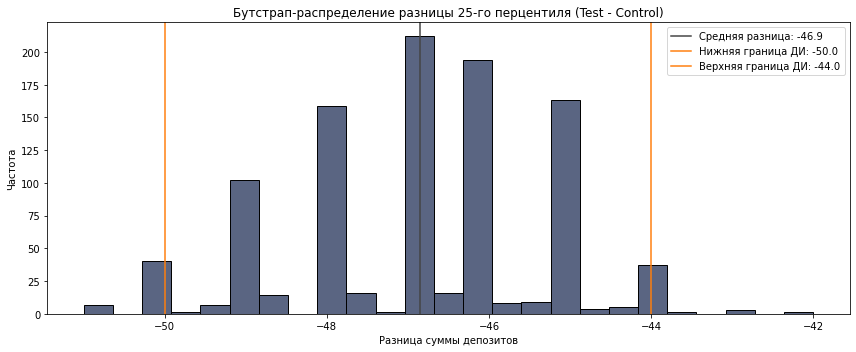

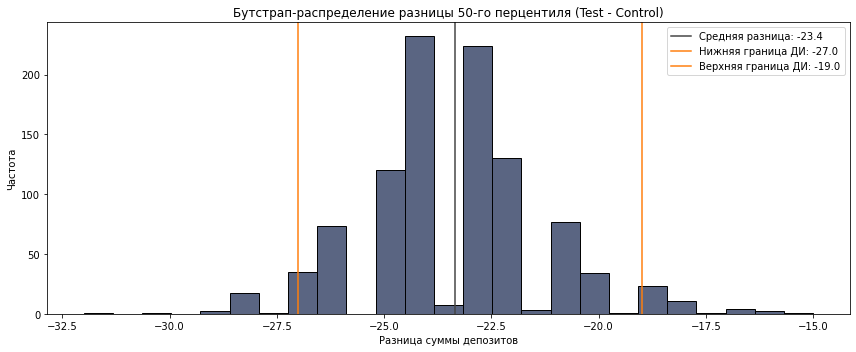

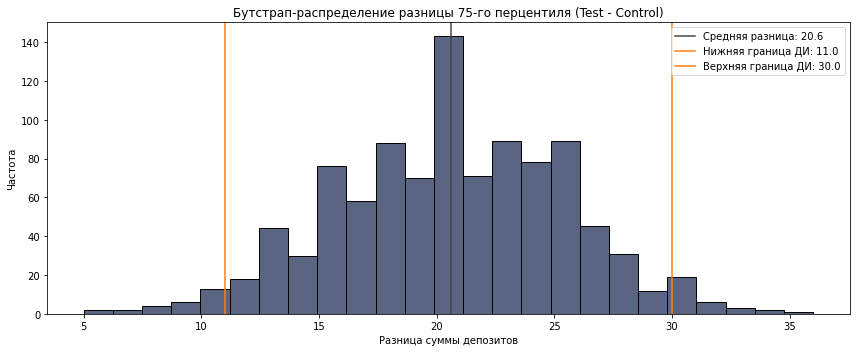

In [66]:
# Визуализация распределения разниц перцентилей
for p in percentiles:
    boot_diffs = boot_diffs_dict[p]       
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])
    mean_diff = np.mean(boot_diffs)
    
    plt.figure(figsize=(12, 5)) 
    plt.hist(
        boot_diffs,
        bins=25,
        color='#586381',
        edgecolor='black',
        alpha=0.99
    )
    plt.axvline(mean_diff, color='#444444', linestyle='solid', label=f'Средняя разница: {mean_diff:.1f}')
    plt.axvline(diff_ci[0], color='#ff7f0e', linestyle='solid', label=f'Нижняя граница ДИ: {diff_ci[0]:.1f}')
    plt.axvline(diff_ci[1], color='#ff7f0e', linestyle='solid', label=f'Верхняя граница ДИ: {diff_ci[1]:.1f}')
    
    plt.title(f'Бутстрап-распределение разницы {p}-го перцентиля (Test - Control)')
    plt.xlabel('Разница суммы депозитов')
    plt.ylabel('Частота')
    plt.legend(loc='upper right')
    plt.gca().set_facecolor('white')
    plt.tight_layout()
    plt.show()

- **25-й перцентиль:** нижняя четверть платящих пользователей в тестовой группе стала намного осторожнее и вносит меньше депозитов, чем аналогичная часть в контрольной группе. Это подтверждает гипотезу риска: детальный онбординг отпугнул часть самых осторожных новичков, снизив их активность.


- **50-й перцентиль:** медиана также снизилась в тестовой группе, но не так резко, как нижний перцентиль. Середина распределения показывает умеренное снижение депозитов, то есть средний пользователь стал немного более осторожным, но изменения не критичны.


- **75-й перцентиль:** верхняя четверть пользователей, склонных к крупным депозитам, увеличила свои вложения. Это подтверждает гипотезу роста: более опытные или рискованные пользователи стали активнее использовать продукт после образовательного онбординга.

<a class="anchor" id="final-conclusions"></a>
### 5 Выводы

**Контекст и цель эксперимента:**
Обновлённый онбординг предоставлял пользователям подробную информацию о видах финансовых активов и связанных с ними рисках. Цель эксперимента - понять, как такой образовательный контент влияет на поведение пользователей и их инвестиционную активность.


**Влияние на ключевые метрики:**
- Ключевая метрика (средняя сумма депозитов на пользователя): не снизилась статистически значимо для всей аудитории.


- Барьерная метрика (конверсия в первый депозит): осталась стабильной.


- Вспомогательные метрики: конверсия во второй депозит и средняя сумма депозитов на платящего пользователя статистически значимо увеличились.


**Основные результаты:**
- Нижний сегмент пользователей (25-й перцентиль):
Сумма депозитов в тестовой группе снизилась с 95 до 48. Доверительный интервал разницы указывает на статистически значимое снижение. Это значит, что часть осторожных пользователей стала более аккуратной или полностью прекратила пополнения. Это подтверждает гипотезу риска, что подробная информация о рисках отпугнула новичков с низкой склонностью к инвестициям.


- Средний сегмент пользователей (50-й перцентиль):
Сумма депозитов снизилась с 118 до 94, разница указывает на умеренное снижение активности в среднем сегменте, что отражает общее осторожное поведение пользователей после обучения.


- Верхний сегмент пользователей (75-й перцентиль):
Сумма депозитов выросла с 159 до 179.5, доверительный интервал указывает, что наиболее активные и рискованные пользователи стали инвестировать больше. Это подтверждает гипотезу роста, что образовательный онбординг усиливает вовлечённость опытных пользователей.


**Рекомендации:**
- Сохранять образовательный контент для пользователей, которые делают крупные депозиты, чтобы они понимали риски активов высокого уровня и могли безопасно инвестировать большие суммы.


- Для новичков с небольшими депозитами сделать пошаговое обучение, постепенно вводя информацию о рисках финансовых активов, с дополнительными инструкциями при первом депозите.


- Продолжать отслеживать поведение разных групп пользователей по величине депозитов, чтобы находить баланс между вовлечением опытных инвесторов и безопасным обучением новичков относительно рискованных инструментов.